In [1]:
import pandas as pd
import os
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_status_metadata.csv')
for key in df.keys():
    if 'Unnamed' in key:df.drop(key, axis=1, inplace=True)

In [3]:
df['toXML.clean']  = df['toXML.clean'] | df['toXML.clean_beta']
df['toXML.revtex'] = df['toXML.revtex'] | df['toXML.revtex_beta']

In [4]:
ready_to_process_df = df[(df['_type'] == 'ready_to_process')]

In [5]:
origin_count = len(df[(df['_type'] == 'ready_to_process')& ( df['toXML.origin'].isin([True]))])
clean_count  = len(df[(df['_type'] == 'ready_to_process')& (~df['toXML.origin'].isin([True])) &  ( df['toXML.clean'].isin([True]))])
revtex_count = len(df[(df['_type'] == 'ready_to_process')& (~df['toXML.origin'].isin([True])) &  (~df['toXML.clean'].isin([True]))&  ( df['toXML.revtex'].isin([True]))])
non_count    = len(df[(df['_type'] == 'ready_to_process')& (~df['toXML.origin'].isin([True])) &  (~df['toXML.clean'].isin([True]))&  (~df['toXML.revtex'].isin([True]))])
print(origin_count)
print(clean_count )
print(revtex_count)
print(non_count   )

1283639
353036
50012
379232


In [6]:
value_counts_pool = df['_type'].value_counts().to_dict()

In [7]:
others = sum(value_counts_pool.values()) - sum([value_counts_pool[name] for name in [
    'ready_to_process','isPDF','skip_via_has_tikz','can_not_find_root','plain_tex'
]])

In [8]:
len(df)

2451510

In [8]:
vals    = [[origin_count, clean_count, revtex_count], 
           [non_count],
           [value_counts_pool['can_not_find_root']+value_counts_pool['multifiles_case'],value_counts_pool['skip_via_has_tikz'], value_counts_pool['plain_tex']], 
           [value_counts_pool['isPDF'], others]
          ] 

In [9]:
#vals = [[1053580, 327334, 50832],[ 668031], [29106, 51641, 14690], [193095, 63201]]

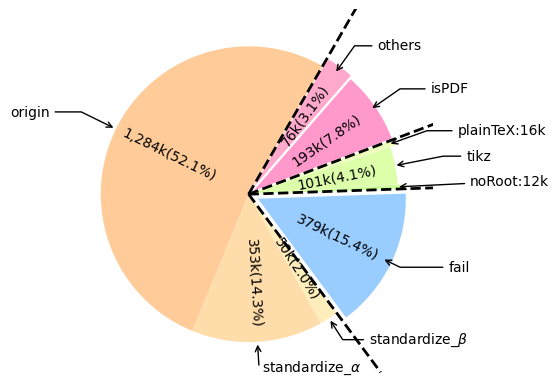

In [9]:
import matplotlib.pyplot as plt
import numpy as np

group_colors = [
    ['#ffcc99', '#ffddaa', '#ffeebb'],  # Warm light oranges for the first group
    ['#99ccff'],                        # Single cool blue for the second group
    ['#ccff99', '#ddffaa', '#eeffbb'],  # Light greens for the third group
    ['#ff99cc', '#ffaacd']              # Light pinks for the fourth group
]

group_explode = [
    [0.0, 0.0, 0.0], 
    [0.07],# Different explode values for slices within the first group
    [0.03, 0.01, 0.05],       # Different explode values for slices within the second group
    [0.04, 0.06]              # Different explode values for slices within the third group
]
flattenvalues = []
colors = []
explodes = []
for t,c,e in zip(vals,group_colors,group_explode):
    flattenvalues.extend(t)
    colors.extend(c)
    explodes.extend(e)
labels2 = ['origin', r'standardize_$\alpha$', r'standardize_$\beta$', 'fail',  'noRoot','tikz', 'plainTeX', 'isPDF', 'others']
sumvalues = [np.sum(t) for t in vals]
labels1 = ['good_tex', 'fail_tex','confused_tex', 'no_tex']
def custom_autopct(pct):
    total = sum(flattenvalues)
    val    = int(round(pct * total / 100.0/1000))
    return f"{val:,}k({pct:.1f}%)"
# Create the pie chart

start_angle = 60
fig, ax = plt.subplots()
wedges, texts, autotexts = ax.pie(flattenvalues, explode=explodes,autopct=custom_autopct, colors=colors, startangle=start_angle, textprops={'rotation_mode': 'anchor', 'ha': 'center'})

cumsum     = np.cumsum([0]+sumvalues)
angles     = cumsum[:-1]/cumsum[-1]*360 + start_angle 
angles_rad = [np.radians(a) for a in angles]

for angle_rad in angles_rad:
    ax.plot([0, 1.5 * np.cos(angle_rad)], [0, 1.5 * np.sin(angle_rad)], color='black',linewidth=2, linestyle='--')

for label,val, autotext, wedge in zip(labels2, flattenvalues,autotexts, wedges):
    angle_deg = (wedge.theta2 - wedge.theta1) / 2 + wedge.theta1
    
    angle_rad = np.deg2rad(angle_deg)
    rotation  = np.rad2deg(angle_rad)
    # Adjust the rotation such that text is always upright
    if angle_deg > 90 and angle_deg < 270:
        rotation  = rotation - 180 
 
    autotext.set_rotation(rotation)
    autotext.set_horizontalalignment('center')
    
    show_text = wedge.theta2 - wedge.theta1 > 5
    if not show_text:
        autotext.set_text('')
    p = wedge
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    x = np.cos(np.deg2rad(ang))
    y = np.sin(np.deg2rad(ang))
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    connectionstyle = "angle,angleA=0,angleB={}".format(ang)
    if not show_text:
        val = int(np.round(val/1000))
        label = f"{label}:{val}k"
    height_distinguish = 1.2 if show_text else 1.5
    #print(label, (x, y))
    ax.annotate(label, xy=(x, y), xytext=(1.5*x, 1.2*y),
                horizontalalignment=horizontalalignment, 
                arrowprops=dict(arrowstyle="->", 
                connectionstyle=connectionstyle))

plt.show()
os.makedirs('figures',exist_ok=True)
fig.savefig('figures/uparxive_analysis.png',dpi=300, bbox_inches='tight')

In [137]:
arxivdis_in_success_xml  = os.listdir('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/successed_xml/')
arxivdis_in_success_json = os.listdir('/nvme/zhangtianning.di/sharefold/whole_arxiv_all_files/archive_json/')

FileNotFoundError: [Errno 2] No such file or directory: '/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/successed_xml/'

In [25]:
arxivid

'2306.07943'

In [32]:
import shutil
from pathlib import Path
ROOT='/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/successed_xml/'
arxivdis_in_success_xml  = os.listdir(ROOT)
with open('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/analysis/successed_xml.filelist','w') as f:
    for arxivid in tqdm(arxivdis_in_success_xml):
        arixivpath = os.path.join(ROOT,arxivid)
        filepath   = list(Path(arixivpath).glob('*.xml'))
        if len(filepath) ==0:
            print(arxivid)
            continue
        f.write(str(filepath[0])+'\n')
    

  0%|          | 0/929 [00:00<?, ?it/s]

In [11]:
len(arxivdis_in_success_xml)

343243

In [12]:
len(arxivdis_in_success_json)

1389731

In [13]:
arxivdis_in_success_xml_set = set(arxivdis_in_success_xml)
arxivdis_in_success_json_set= set(arxivdis_in_success_json)

In [14]:
repeat = set(arxivdis_in_success_xml_set) & set(arxivdis_in_success_json_set)

In [18]:
for i, arxivid in enumerate(repeat):
    print(f"{arxivid}")
    if i > 20 :break

cond-mat_0204139
quant-ph_0005079
1801.08494
math-ph_0302032
2203.10832
astro-ph_9611201
hep-ph_0102190
hep-ph_9510318
astro-ph_0307207
hep-ph_0603018
hep-th_0405160
2102.10344
1110.0540
hep-ph_0303138
2305.00716
hep-ph_9802298
hep-th_9405044
1704.09016
astro-ph_9806139
hep-ph_9610409
1005.1208
1010.5911


In [140]:
len(os.listdir('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/archive_xml/'))

307777

In [138]:
len(os.listdir('/nvme/zhangtianning/datasets/whole_arxiv_data/whole_arxiv_all_files/archive_json/'))

307777

In [15]:
len(repeat)

34781